# AI-Accelerated QEC for Neutral-Atom Logical Qubits

This interactive companion to Infleqtion’s [AI-accelerated QEC post](https://infleqtion.com/ai-accelerated-qec/) turns its leakage-aware NVIDIA Ising Decoding experiment into runnable cells. It keeps the experiment deliberately transparent: change the leakage probabilities, number of shots, and execution mode, regenerate the metrics, and inspect the resulting logical-error-rate and decoder-latency plots.

> **Heuristic simulation.** This notebook injects leakage transitions after two-qubit Clifford gates on top of a fixed circuit-level Pauli noise model for a distance-9 surface-code memory experiment. It is an exploration tool, not a hardware-calibrated prediction.

## Why decoding matters

QEC is both a quantum and a classical-computing problem. Every correction round creates syndrome data that must be processed fast enough to keep pace with the hardware. NVIDIA Ising Decoding provides a learned GPU-resident pass that sparsifies syndrome information before downstream decoding, reducing the classical burden while retaining information needed for correction.

For neutral atoms, this is especially relevant as measurement and control loops become faster: useful logical qubits require accuracy, throughput, and low decoding latency together.

## Neutral atoms are qubits in theory, but qudits in practice

Neutral-atom hardware can occupy levels outside the computational subspace. In this simplified model, `|0L⟩` and `|1L⟩` leak out of the computational space but are still read as 0-like and 1-like outcomes. The decoder therefore sees leakage indirectly through a syndrome stream shaped by both Pauli-type noise and out-of-subspace population.

Run the next cell to explore that binary readout mapping.

In [1]:
def map_readout_state(level: int) -> int:
    """Map computational and leakage levels to a binary readout."""
    zero_like = {0, 2}  # |0⟩ and |0L⟩
    one_like = {1, 3}   # |1⟩ and |1L⟩
    if level in zero_like:
        return 0
    if level in one_like:
        return 1
    raise ValueError(f"Unexpected state label: {level}")

for level, label in enumerate(("|0⟩", "|1⟩", "|0L⟩", "|1L⟩")):
    print(f"{label:4} → observed binary outcome {map_readout_state(level)}")

|0⟩  → observed binary outcome 0
|1⟩  → observed binary outcome 1
|0L⟩ → observed binary outcome 0
|1L⟩ → observed binary outcome 1


## Experiment setup

Install the [`loss_decoder` branch](https://github.com/vtomole/Ising-Decoding/tree/loss_decoder) of `vtomole/Ising-Decoding` into this notebook's Python environment:

```bash
%pip install "git+https://github.com/vtomole/Ising-Decoding.git@loss_decoder"
```

This is a regular pip install—no local checkout or repository-path environment variable is needed. The package includes the public configuration and the R=9/R=13 model files. Because they are stored with Git LFS, install `git-lfs` on the system first (`sudo apt-get install git-lfs && git lfs install`) if it is not already available. Restart the kernel after installing. The CPU configuration is a smoke test; it produces a useful sanity check but not a statistically meaningful curve. Use the GPU configuration for the full nine-point sweep described in the post (262,144 shots per basis).

In [2]:
import json
import os
import re
import subprocess
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12})
%config InlineBackend.figure_format = 'retina'

In [3]:
try:
    from ising_decoding import model_path
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "Install Ising-Decoding with the %pip command in the setup instructions, then restart the kernel."
    ) from exc

checkpoint = model_path("fast")  # public R=9 model bundled with the package
notebook_dir = Path.cwd().resolve()
base_dir = notebook_dir / "outputs/ising_decoder_leakage_model_1/leakage_data"
reference_dir = notebook_dir / "precomputed_metrics"
print(f"Using pip-installed Ising-Decoding model: {checkpoint}")
print(f"Bundled reference metrics: {reference_dir}")

Using pip-installed Ising-Decoding model: /home/cudaq/.local/ising_decoding/models/Ising-Decoder-SurfaceCode-1-Fast.pt
Bundled reference metrics: /home/cudaq/cuda-q-academic/ieee_26_decoding/precomputed_metrics


## Run controls

The default workshop workflow plots the bundled full-sweep reference curve immediately. Set `RUN_GENERATION = True` to generate one short `p = 1e-4` point on the participant's GPU; the notebook overlays it on the reference curve with a star. Use `gpu` only to regenerate the complete, publication-style sweep. Set `OVERWRITE_EXISTING = True` to regenerate the local point after changing its controls.

In [4]:
# Change these values, then run this cell and the next one.
RUN_GENERATION = False
EXECUTION_MODE = "workshop"  # choose "cpu_test", "workshop", or "gpu"
OVERWRITE_EXISTING = False
USE_PREGENERATED_REFERENCE_DATA = True

if EXECUTION_MODE == "cpu_test":
    LEAKAGE_PROBABILITIES = ("1e-4",)
    NUM_SHOTS_PER_BASIS = 32
    LATENCY_TIMING_SAMPLES = 64
elif EXECUTION_MODE == "workshop":
    # One visibly generated point, sized for an interactive GPU session.
    LEAKAGE_PROBABILITIES = ("1e-4",)
    NUM_SHOTS_PER_BASIS = 512
    LATENCY_TIMING_SAMPLES = 64
elif EXECUTION_MODE == "gpu":
    LEAKAGE_PROBABILITIES = (
        "1e-3", "3e-4", "1e-4", "3e-5", "1e-5",
        "3e-6", "1e-6", "3e-7", "1e-7",
    )
    NUM_SHOTS_PER_BASIS = 262_144
    LATENCY_TIMING_SAMPLES = 10_000
else:
    raise ValueError("EXECUTION_MODE must be 'cpu_test', 'workshop', or 'gpu'.")

print({
    "mode": EXECUTION_MODE,
    "leakage_probabilities": LEAKAGE_PROBABILITIES,
    "shots_per_basis": NUM_SHOTS_PER_BASIS,
    "latency_timing_samples": LATENCY_TIMING_SAMPLES,
    "use_precomputed_reference_data": USE_PREGENERATED_REFERENCE_DATA,
})

{'mode': 'workshop', 'leakage_probabilities': ('1e-4',), 'shots_per_basis': 512, 'latency_timing_samples': 64, 'use_precomputed_reference_data': True}


In [5]:
if RUN_GENERATION:
    runner_python = Path(sys.executable).resolve()

    dependency_check = subprocess.run(
        [str(runner_python), "-c", "import torch, leaky"],
        text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    )
    if dependency_check.returncode != 0:
        raise RuntimeError(
            "Leakage inference requires PyTorch and leakysim in the notebook environment.\n"
            "Reinstall the Ising-Decoding package in this kernel, then restart it.\n"
            + dependency_check.stdout.strip()
        )

    base_dir.mkdir(parents=True, exist_ok=True)
    for leakage_probability in LEAKAGE_PROBABILITIES:
        metrics_path = base_dir / f"inference_metrics_p{leakage_probability}_d9_all_leak.json"
        if metrics_path.exists() and not OVERWRITE_EXISTING:
            print(f"Skipping existing metrics: {metrics_path.name}")
            continue

        env = os.environ.copy()
        env.update({
            "WORKFLOW": "inference",
            "EXPERIMENT_NAME": "ising_decoder_leakage_model_1",
            "DISTANCE": "9",
            "N_ROUNDS": "9",
            "ISING_DECODING_MODEL_CHECKPOINT_FILE": str(checkpoint),
            "ISING_DECODING_LEAKAGE_ERROR": leakage_probability,
            "ISING_DECODING_INFERENCE_METRICS_JSON": str(metrics_path),
            "ISING_DECODING_INFERENCE_NUM_SAMPLES": str(NUM_SHOTS_PER_BASIS),
            "ISING_DECODING_INFERENCE_LATENCY_SAMPLES": str(LATENCY_TIMING_SAMPLES),
            "ISING_DECODING_INFERENCE_NUM_WORKERS": "0",
            "ISING_DECODING_TORCH_COMPILE": "1" if EXECUTION_MODE == "gpu" else "0",
        })
        print(f"Generating metrics for leakage probability {leakage_probability}...")
        subprocess.run(
            [str(runner_python), "-m", "ising_decoding", "++load_checkpoint=True"],
            cwd=Path.cwd(),
            env=env,
            check=True,
        )

generated_paths = sorted(base_dir.glob("inference_metrics_p*_d9_all_leak.json"))
reference_paths = (
    sorted(reference_dir.glob("inference_metrics_p*_d9_all_leak.json"))
    if USE_PREGENERATED_REFERENCE_DATA else []
)
if USE_PREGENERATED_REFERENCE_DATA and not reference_paths:
    raise RuntimeError(f"No bundled reference metrics found under {reference_dir}.")

# A locally generated point replaces the bundled point at the same leakage probability.
metrics_by_filename = {path.name: path for path in reference_paths}
metrics_by_filename.update({path.name: path for path in generated_paths})
paths = sorted(metrics_by_filename.values())
if not paths:
    raise RuntimeError(
        f"No leakage metrics found under {base_dir}. Set RUN_GENERATION = True to create them."
    )
print(
    f"Using {len(paths)} metric file(s): {len(generated_paths)} generated locally, "
    f"{len(reference_paths)} bundled reference file(s)."
)

Using 8 metric file(s): 1 generated locally, 8 bundled reference file(s).


## Results: leakage-aware logical performance

The post’s central experimental question is whether learned, AI-assisted decoding remains useful once leakage is included. The cells below compare the PyMatching-only baseline with the pipeline after the Ising decoder, averaging over X and Z bases.

For the workshop, eight precomputed full-sweep points are bundled with the notebook. A locally generated `p = 1e-4` point replaces the matching bundled point and is marked with a star, showing how the JSON produced by the generation cell feeds the final graph.

In [6]:
def leakage_probability_from_filename(path: Path) -> float:
    match = re.search(r"_p([0-9]+(?:e-?\d+)?)_d9_all_leak\.json$", path.name)
    if not match:
        raise ValueError(f"Could not parse leakage probability from {path.name}")
    return float(match.group(1))

generated_path_set = {path.resolve() for path in generated_paths}
rows = []
for path in paths:
    metrics = json.loads(path.read_text())
    rows.append({
        "leakage_probability": leakage_probability_from_filename(path),
        "ler_baseline": float(metrics["ler"]["avg"]["baseline"]),
        "ler_ising": float(metrics["ler"]["avg"]["after_ising_decoder"]),
        "latency_baseline_us": float(metrics["pymatching_latency_us_per_round"]["avg"]["baseline"]),
        "latency_ising_us": float(metrics["pymatching_latency_us_per_round"]["avg"]["after_ising_decoder"]),
        "generated_locally": path.resolve() in generated_path_set,
    })
rows.sort(key=lambda row: row["leakage_probability"])

for row in rows:
    print(
        f"p={row['leakage_probability']:.1e} | "
        f"LER baseline={row['ler_baseline']:.6f}, Ising={row['ler_ising']:.6f} | "
        f"latency baseline={row['latency_baseline_us']:.3f} µs/round, "
        f"Ising={row['latency_ising_us']:.3f} µs/round | "
        f"source={'generated here' if row['generated_locally'] else 'bundled reference'}"
    )

p=1.0e-07 | LER baseline=0.397596, Ising=0.022995 | latency baseline=1.822 µs/round, Ising=0.549 µs/round | source=bundled reference
p=3.0e-07 | LER baseline=0.396542, Ising=0.023554 | latency baseline=1.800 µs/round, Ising=0.548 µs/round | source=bundled reference
p=1.0e-06 | LER baseline=0.397144, Ising=0.023521 | latency baseline=1.373 µs/round, Ising=0.404 µs/round | source=bundled reference
p=3.0e-06 | LER baseline=0.398211, Ising=0.023869 | latency baseline=1.750 µs/round, Ising=0.492 µs/round | source=bundled reference
p=1.0e-05 | LER baseline=0.398918, Ising=0.025393 | latency baseline=1.843 µs/round, Ising=0.558 µs/round | source=bundled reference
p=3.0e-05 | LER baseline=0.398783, Ising=0.030622 | latency baseline=1.392 µs/round, Ising=0.410 µs/round | source=bundled reference
p=3.0e-04 | LER baseline=0.413147, Ising=0.092005 | latency baseline=1.602 µs/round, Ising=0.474 µs/round | source=bundled reference
p=1.0e-03 | LER baseline=0.443123, Ising=0.214083 | latency baseline=

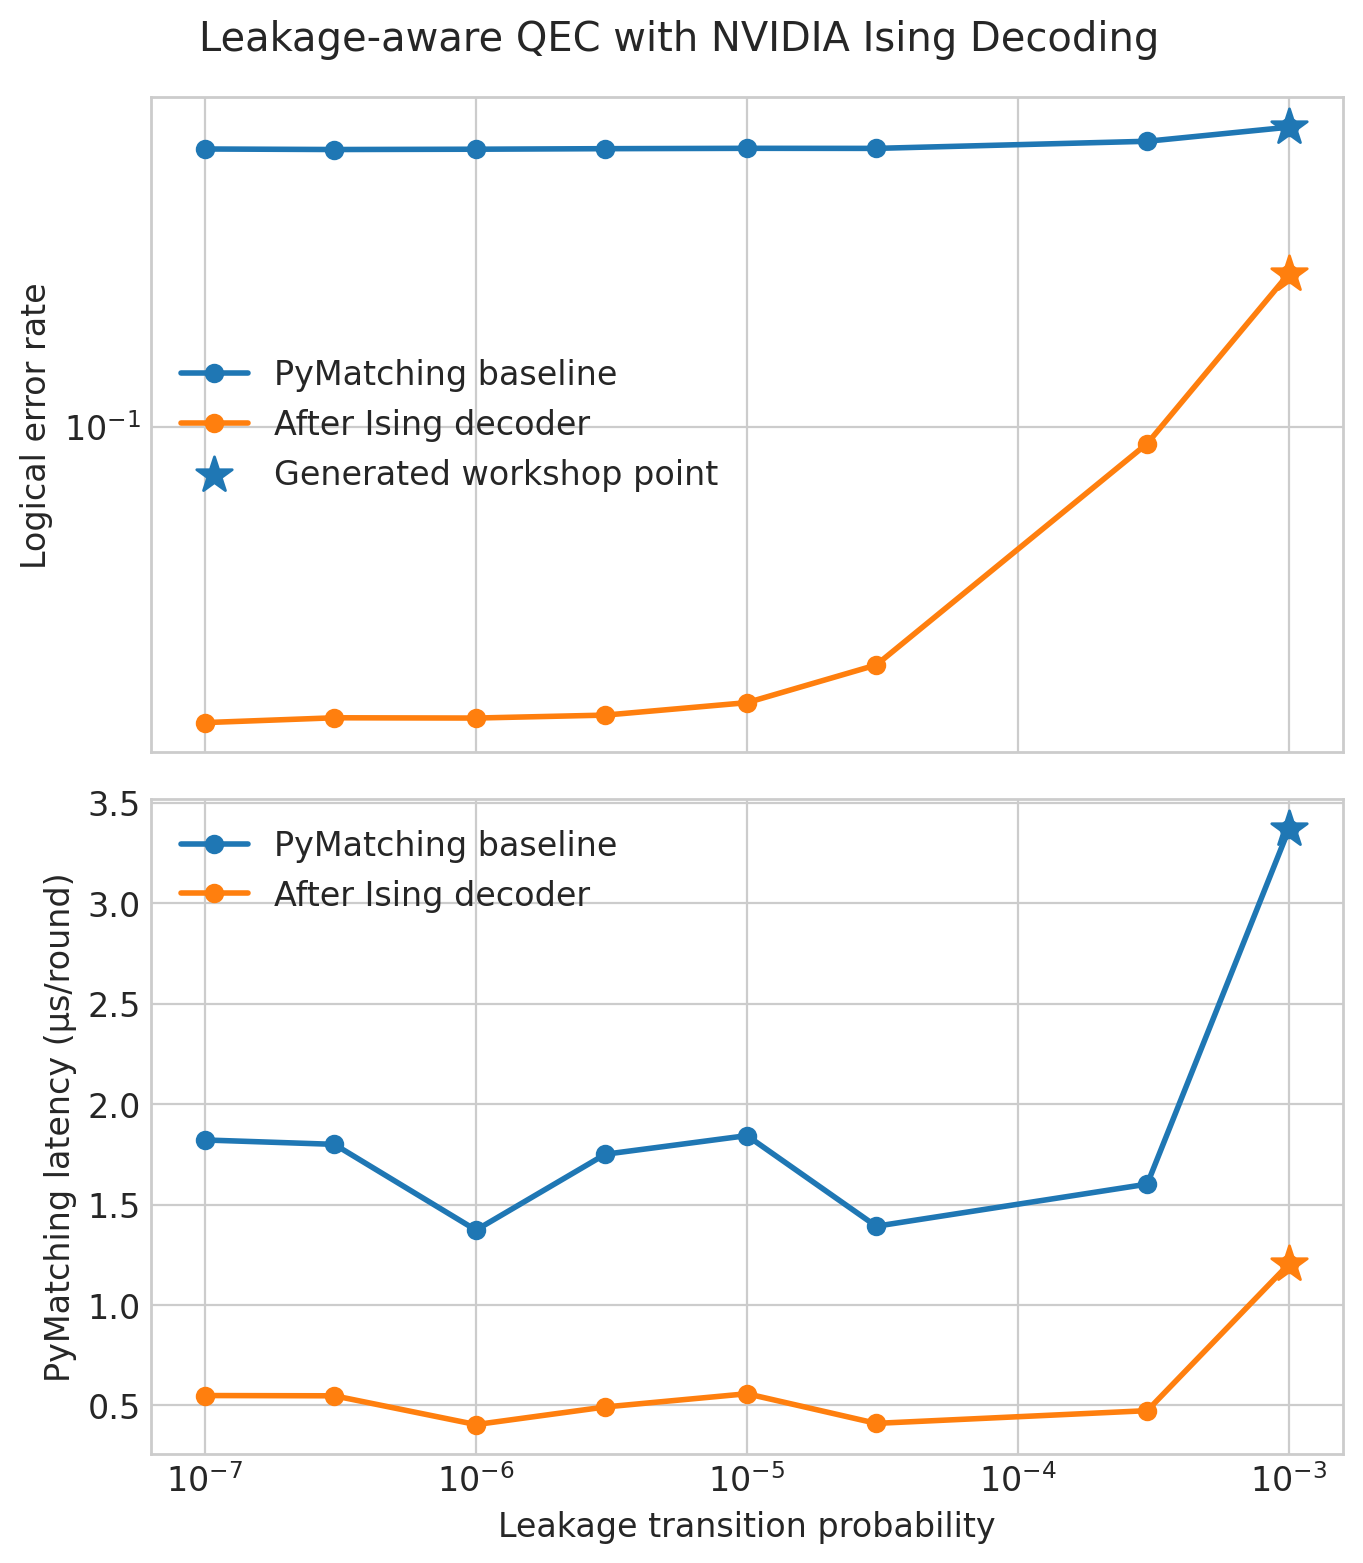

In [7]:
x = np.array([row["leakage_probability"] for row in rows])
ler_baseline = np.array([row["ler_baseline"] for row in rows])
ler_ising = np.array([row["ler_ising"] for row in rows])
latency_baseline = np.array([row["latency_baseline_us"] for row in rows])
latency_ising = np.array([row["latency_ising_us"] for row in rows])
generated_locally = np.array([row["generated_locally"] for row in rows])

plt.style.use("seaborn-v0_8-whitegrid")
fig, (ax_ler, ax_latency) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
ax_ler.plot(x, ler_baseline, marker="o", linewidth=2, label="PyMatching baseline")
ax_ler.plot(x, ler_ising, marker="o", linewidth=2, label="After Ising decoder")
if np.any(generated_locally):
    ax_ler.scatter(x[generated_locally], ler_baseline[generated_locally], marker="*", s=180, zorder=3, color="tab:blue", label="Generated workshop point")
    ax_ler.scatter(x[generated_locally], ler_ising[generated_locally], marker="*", s=180, zorder=3, color="tab:orange")
ax_ler.set_xscale("log")
ax_ler.set_yscale("log")
ax_ler.set_ylabel("Logical error rate")
ax_ler.legend(loc="best")

finite_latency = np.isfinite(latency_baseline) & np.isfinite(latency_ising)
if np.any(finite_latency):
    ax_latency.plot(x[finite_latency], latency_baseline[finite_latency], marker="o", linewidth=2, label="PyMatching baseline")
    ax_latency.plot(x[finite_latency], latency_ising[finite_latency], marker="o", linewidth=2, label="After Ising decoder")
    local_latency = finite_latency & generated_locally
    if np.any(local_latency):
        ax_latency.scatter(x[local_latency], latency_baseline[local_latency], marker="*", s=180, zorder=3, color="tab:blue")
        ax_latency.scatter(x[local_latency], latency_ising[local_latency], marker="*", s=180, zorder=3, color="tab:orange")
    ax_latency.set_xscale("log")
    ax_latency.set_ylabel("PyMatching latency (µs/round)")
    ax_latency.legend(loc="best")
else:
    ax_latency.text(0.5, 0.5, "No latency samples were collected.\nSet LATENCY_TIMING_SAMPLES > 0 and regenerate metrics.", ha="center", va="center", transform=ax_latency.transAxes)
    ax_latency.set_axis_off()

ax_latency.set_xlabel("Leakage transition probability")
fig.suptitle("Leakage-aware QEC with NVIDIA Ising Decoding", y=0.98)
fig.tight_layout()
plt.show()

## From leakage to erasure

Leakage is not always an opaque error channel. If leakage or atom loss is detected, its location can be surfaced as an erasure signal. That does not reveal the error value, but it constrains where the decoder must search. A forward-looking neutral-atom stack can identify leakage or loss, convert it to erasure information, train the Ising model on that richer signal, and pass an easier problem to downstream decoding.

This notebook models binary leakage readout only. It does not yet model detected loss, erasure conversion, or an erasure-aware trained decoder. Those are natural extensions rather than claims supported by the current cells.

## Why this matters for Sqale

The broader objective is a coherent hybrid QPU–GPU stack: strong physical qubits, scalable logical architectures, GPU-resident classical acceleration, and AI models that make control and decoding faster and more informed. For neutral atoms, realistic leakage-aware simulation is one way to connect hardware physics to that decoding stack.

Read the full [published post](https://infleqtion.com/ai-accelerated-qec/) for the neutral-atom context, platform roadmap, and source figures. This notebook is the executable companion for the leakage-aware decoding experiment.